# Student 3 — Defect Detection
## Notebook 02: Faster R-CNN (two-stage)

**Algorithm.** Faster R-CNN is the two-stage detector of Section 2.4.2. A ResNet-50 + FPN backbone
produces multi-scale feature maps; a Region Proposal Network (RPN) slides over them and emits class
-agnostic candidate regions with an objectness score; RoIAlign then pools each candidate to a fixed
7x7 grid, and a detection head classifies it and refines its box. The extra proposal stage is what
gives the architecture its accuracy advantage on small, densely packed anomalies — and its higher
latency.

**Prerequisite.** Run `00_data_preparation.ipynb` first. This notebook consumes
`dataset/coco/instances_*.json` and writes `results/faster_rcnn.json`.

### 1. Environment

`torchvision` supplies the reference Faster R-CNN implementation, `torchmetrics` the COCO-style mAP
so that the numbers are directly comparable with the Ultralytics figures from notebooks 01 and 03.

In [1]:
# Run once per environment (remove the leading '#' the first time)
# %pip install -q torch torchvision torchmetrics pycocotools

In [2]:
import json, math, random, time, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import functional as TF
from torchmetrics.detection import MeanAveragePrecision

warnings.filterwarnings("ignore")

CUDA   = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA else "cpu")
print("torch      :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("device     :", torch.cuda.get_device_name(0) if CUDA else "CPU (training will be slow)")

torch      : 2.13.0+cpu
torchvision: 0.28.0+cpu
device     : CPU (training will be slow)


### 2. Load the prepared dataset

The same `dataset_info.json` written by notebook 00 is used, so the split is byte-for-byte
identical to the one YOLOv10 and RT-DETR see. Note the class-id convention: COCO ids run 1..6 here
because torchvision reserves id **0 for background**.

In [3]:
def find_work_dir(start: Path) -> Path:
    for c in [start, *start.parents]:
        if (c / "dataset" / "dataset_info.json").is_file():
            return c
        if (c / "Student3-Defect Detection" / "dataset" / "dataset_info.json").is_file():
            return c / "Student3-Defect Detection"
    raise FileNotFoundError("dataset_info.json not found - run 00_data_preparation.ipynb first.")

WORK_DIR    = find_work_dir(Path.cwd())
INFO        = json.loads((WORK_DIR / "dataset" / "dataset_info.json").read_text())
CLASS_NAMES = INFO["class_names"]
NUM_CLASSES = len(CLASS_NAMES) + 1          # +1 for background
COCO_DIR    = Path(INFO["paths"]["coco_dir"])
IMG_ROOT    = Path(INFO["paths"]["yolo_root"]) / "images"   # images live here (not duplicated)
RESULTS_DIR = WORK_DIR / "results"; RESULTS_DIR.mkdir(exist_ok=True)
CKPT_DIR    = WORK_DIR / "runs" / "faster_rcnn"; CKPT_DIR.mkdir(parents=True, exist_ok=True)

print("Work dir  :", WORK_DIR)
print("COCO dir  :", COCO_DIR)
print("Split     :", INFO["counts"], "| boxes:", INFO["boxes"])
print("Classes   :", {i + 1: n for i, n in enumerate(CLASS_NAMES)}, "| 0 = background")

Work dir  : C:\Users\User\Image-Processing\Student3-Defect Detection
COCO dir  : C:\Users\User\Image-Processing\Student3-Defect Detection\dataset\coco
Split     : {'train': 483, 'val': 138, 'test': 72} | boxes: {'train': 2051, 'val': 598, 'test': 304}
Classes   : {1: 'missing_hole', 2: 'mouse_bite', 3: 'open_circuit', 4: 'short', 5: 'spur', 6: 'spurious_copper'} | 0 = background


### 3. Dataset and data loaders

A minimal COCO reader is enough here — the full `pycocotools` dataset class adds nothing for a
single-folder dataset. Boxes are converted from COCO `[x, y, w, h]` to the `[x1, y1, x2, y2]`
format torchvision expects. The only augmentation is a random horizontal flip on the training split
(with the boxes mirrored accordingly); PCB images are captured in a fixed orientation, so aggressive
geometric augmentation would not reflect the deployment conditions.

In [4]:
class PCBCocoDataset(Dataset):
    def __init__(self, img_dir: Path, ann_file: Path, train: bool = False, seed: int = 0):
        data = json.loads(Path(ann_file).read_text())
        self.img_dir = Path(img_dir)
        self.train   = train
        self.images  = data["images"]
        self.by_img  = defaultdict(list)
        for a in data["annotations"]:
            self.by_img[a["image_id"]].append(a)
        self.rng = random.Random(seed)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        rec = self.images[idx]
        img = Image.open(self.img_dir / rec["file_name"]).convert("RGB")
        boxes, labels = [], []
        for a in self.by_img[rec["id"]]:
            x, y, w, h = a["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(a["category_id"])          # already 1-based
        boxes  = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        img    = TF.to_tensor(img)

        if self.train and self.rng.random() < 0.5:            # horizontal flip
            img = torch.flip(img, dims=[2])
            W = img.shape[2]
            if boxes.numel():
                boxes = torch.stack([W - boxes[:, 2], boxes[:, 1],
                                     W - boxes[:, 0], boxes[:, 3]], dim=1)

        target = {
            "boxes":    boxes,
            "labels":   labels,
            "image_id": torch.tensor([rec["id"]]),
            "area":     (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd":  torch.zeros((len(labels),), dtype=torch.int64),
        }
        return img, target


def collate(batch):
    return tuple(zip(*batch))


BATCH_SIZE  = 4 if CUDA else 2
NUM_WORKERS = 2 if CUDA else 0

datasets = {s: PCBCocoDataset(IMG_ROOT / s, COCO_DIR / f"instances_{s}.json",
                              train=(s == "train"), seed=INFO["random_seed"])
            for s in ("train", "val", "test")}
loaders = {s: DataLoader(d, batch_size=BATCH_SIZE, shuffle=(s == "train"),
                         num_workers=NUM_WORKERS, collate_fn=collate)
           for s, d in datasets.items()}

for s, d in datasets.items():
    print(f"{s:<6} {len(d):3d} images, {sum(len(v) for v in d.by_img.values()):4d} boxes")

img0, tgt0 = datasets["train"][0]
print("\nSample tensor:", tuple(img0.shape), "| boxes:", tuple(tgt0["boxes"].shape),
      "| labels:", tgt0["labels"].tolist())

train  483 images, 2051 boxes
val    138 images,  598 boxes
test    72 images,  304 boxes

Sample tensor: (3, 512, 512) | boxes: (5, 4) | labels: [1, 1, 1, 1, 1]


### 4. Build the model

Two modifications are made to the stock torchvision model:

1. **Head replacement.** The COCO box predictor (91 classes) is swapped for a fresh
   `FastRCNNPredictor` with 7 outputs (6 defects + background). The backbone, FPN and RPN keep
   their pretrained weights.
2. **Smaller anchors.** Notebook 00 showed that the defects occupy roughly 10–25 px on a 512 px
   image. The default anchor sizes (32–512 px) are far too large for that, so the RPN would propose
   almost nothing useful. The anchor generator is rebuilt with sizes 8–128 px, one size per FPN
   level, keeping the three standard aspect ratios — the RPN head weights stay compatible because
   the number of anchors per location is unchanged.

#### 4a. Getting the COCO weights (read this if the download fails)

torchvision fetches its pretrained weights from `download.pytorch.org`, which some campus, office
and ISP networks block or reset — the symptom is
`URLError: [WinError 10054] An existing connection was forcibly closed by the remote host`.
(Ultralytics is unaffected because it downloads from GitHub instead.)

The next cell retries the download and, if it still fails, tells you exactly where to drop the file.
To fix it manually:

1. Download this file on any working connection — a browser, a phone hotspot, or a friend's machine:
   `https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth` (~170 MB).
   In PowerShell: `curl.exe -L -o fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth`
2. Move it, **keeping the exact file name**, into the checkpoint folder that the next cell prints
   (normally `C:\\Users\\<you>\\.cache\\torch\\hub\\checkpoints\\`).
3. Re-run the cell — it loads from disk and never touches the network again.

As a last resort set `PRETRAINED = False` to train from random initialisation. It will run, but with
483 training images the mAP will be far lower, so say so explicitly in the report rather than
comparing it as if it were a fair fight against the two pretrained models.

In [5]:
import time
from torch.hub import get_dir

SMALL_ANCHORS = True     # set False to keep torchvision's default 32-512 px anchors
PRETRAINED    = True     # set False only if the weights cannot be obtained at all

WEIGHTS_URL  = "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth"
CKPT_CACHE   = Path(get_dir()) / "checkpoints"
CKPT_CACHE.mkdir(parents=True, exist_ok=True)
LOCAL_WEIGHTS = CKPT_CACHE / WEIGHTS_URL.rsplit("/", 1)[-1]

print("Checkpoint folder :", CKPT_CACHE)
print("Expected file     :", LOCAL_WEIGHTS.name,
      "(present)" if LOCAL_WEIGHTS.is_file() else "(not downloaded yet)")


def get_coco_state_dict(retries: int = 3, wait: int = 5):
    """Load the COCO weights from the local cache, downloading them only if needed."""
    if LOCAL_WEIGHTS.is_file():
        print("Using cached weights - no download needed.")
        return torch.load(LOCAL_WEIGHTS, map_location="cpu")
    last = None
    for attempt in range(1, retries + 1):
        try:
            return torch.hub.load_state_dict_from_url(
                WEIGHTS_URL, map_location="cpu", progress=True, check_hash=True)
        except Exception as exc:
            last = exc
            print(f"download attempt {attempt}/{retries} failed: {type(exc).__name__}: {exc}")
            if attempt < retries:
                time.sleep(wait)
    raise RuntimeError(
        "Could not download the Faster R-CNN COCO weights.\n"
        f"Download this file manually:\n  {WEIGHTS_URL}\n"
        f"and place it (same file name) in:\n  {CKPT_CACHE}\n"
        "then re-run this cell. See the notes above this cell.") from last


# Build the architecture without touching the network, then load the weights ourselves
model = fasterrcnn_resnet50_fpn_v2(weights=None, weights_backbone=None, num_classes=91)
if PRETRAINED:
    model.load_state_dict(get_coco_state_dict())
    print("COCO weights loaded.")
else:
    print("WARNING: training from random initialisation - accuracy will be much lower.")

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

if SMALL_ANCHORS:
    model.rpn.anchor_generator = AnchorGenerator(
        sizes=((8,), (16,), (32,), (64,), (128,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5,
    )

model.to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nFaster R-CNN ResNet50-FPN v2 | classes: {NUM_CLASSES} (incl. background)")
print(f"Pretrained: {PRETRAINED} | anchors: {model.rpn.anchor_generator.sizes}")
print(f"Parameters: {n_params/1e6:.2f} M")

Checkpoint folder : C:\Users\User\.cache\torch\hub\checkpoints
Expected file     : fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth (present)
Using cached weights - no download needed.
COCO weights loaded.

Faster R-CNN ResNet50-FPN v2 | classes: 7 (incl. background)
Pretrained: True | anchors: ((8,), (16,), (32,), (64,), (128,))
Parameters: 43.28 M


### 5. Evaluation helpers

`evaluate()` returns COCO-style mAP via `torchmetrics`. `precision_recall_at()` additionally
computes plain precision and recall at a fixed confidence threshold and IoU 0.5 by greedily
matching each prediction to a ground-truth box — this is the quantity the Ultralytics notebooks
report as P and R, so defining it explicitly here keeps the three models comparable.

In [6]:
@torch.no_grad()
def evaluate(model, loader, class_metrics=True):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", class_metrics=class_metrics)
    for imgs, targets in loader:
        preds = model([i.to(DEVICE) for i in imgs])
        preds = [{k: v.detach().cpu() for k, v in p.items()} for p in preds]
        metric.update(preds, [{k: v for k, v in t.items()} for t in targets])
    return metric.compute()


def _iou(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)


@torch.no_grad()
def precision_recall_at(model, loader, score_thr=0.5, iou_thr=0.5):
    model.eval()
    tp = fp = fn = 0
    for imgs, targets in loader:
        preds = model([i.to(DEVICE) for i in imgs])
        for p, t in zip(preds, targets):
            keep = p["scores"].cpu().numpy() >= score_thr
            pb = p["boxes"].cpu().numpy()[keep]; pl = p["labels"].cpu().numpy()[keep]
            ps = p["scores"].cpu().numpy()[keep]
            order = np.argsort(-ps); pb, pl = pb[order], pl[order]
            gb = t["boxes"].numpy(); gl = t["labels"].numpy()
            used = np.zeros(len(gb), dtype=bool)
            ious = _iou(pb, gb)
            for i in range(len(pb)):
                best, best_j = 0.0, -1
                for j in range(len(gb)):
                    if used[j] or gl[j] != pl[i]:
                        continue
                    if ious[i, j] > best:
                        best, best_j = ious[i, j], j
                if best >= iou_thr:
                    used[best_j] = True; tp += 1
                else:
                    fp += 1
            fn += int((~used).sum())
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    return {"precision": precision, "recall": recall, "tp": tp, "fp": fp, "fn": fn}

print("Evaluation helpers ready.")

Evaluation helpers ready.


### 6. Train

SGD with momentum is the schedule used in the original paper; a short linear warm-up avoids the
loss spike that a freshly initialised detection head otherwise causes. After every epoch the model
is evaluated on the validation split and the checkpoint with the best `mAP@0.5:0.95` is kept, which
is the two-stage equivalent of the early stopping Ultralytics performs internally.

> **Runtime warning.** Faster R-CNN ResNet50-FPN is heavy. On a GPU expect a few minutes per epoch;
> on CPU expect 20–40 minutes per epoch — lower `EPOCHS` to 2–3 if you have no GPU, purely to prove
> the pipeline runs, and report the GPU numbers in the documentation.

In [7]:
EPOCHS    = 20 if CUDA else 3
LR        = 0.005
MOMENTUM  = 0.9
WD        = 5e-4
WARMUP    = 200          # iterations

params    = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.cuda.amp.GradScaler(enabled=CUDA)

history   = {"epoch": [], "train_loss": [], "val_map50": [], "val_map": []}
best_map, best_epoch = -1.0, -1
BEST_CKPT = CKPT_DIR / "best.pt"
step = 0
t0 = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running, nb = 0.0, 0
    for imgs, targets in loaders["train"]:
        imgs    = [i.to(DEVICE) for i in imgs]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        if step < WARMUP:                                   # linear warm-up
            for g in optimizer.param_groups:
                g["lr"] = LR * (step + 1) / WARMUP
        step += 1

        with torch.cuda.amp.autocast(enabled=CUDA):
            losses = model(imgs, targets)
            loss = sum(losses.values())
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        running += float(loss); nb += 1

    scheduler.step()
    val = evaluate(model, loaders["val"], class_metrics=False)
    tl, m50, m = running / max(nb, 1), float(val["map_50"]), float(val["map"])
    history["epoch"].append(epoch); history["train_loss"].append(tl)
    history["val_map50"].append(m50); history["val_map"].append(m)
    print(f"epoch {epoch:>3}/{EPOCHS} | train loss {tl:.4f} | val mAP50 {m50:.4f} | val mAP50-95 {m:.4f}")

    if m > best_map:
        best_map, best_epoch = m, epoch
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_map": m}, BEST_CKPT)

train_time = time.perf_counter() - t0
print(f"\nTraining finished in {train_time/60:.1f} min | best epoch {best_epoch} (val mAP50-95 {best_map:.4f})")

epoch   1/3 | train loss 0.2449 | val mAP50 0.0443 | val mAP50-95 0.0114
epoch   2/3 | train loss 0.1532 | val mAP50 0.3192 | val mAP50-95 0.1026
epoch   3/3 | train loss 0.1505 | val mAP50 0.4193 | val mAP50-95 0.1351

Training finished in 182.2 min | best epoch 3 (val mAP50-95 0.1351)


### 7. Training curves

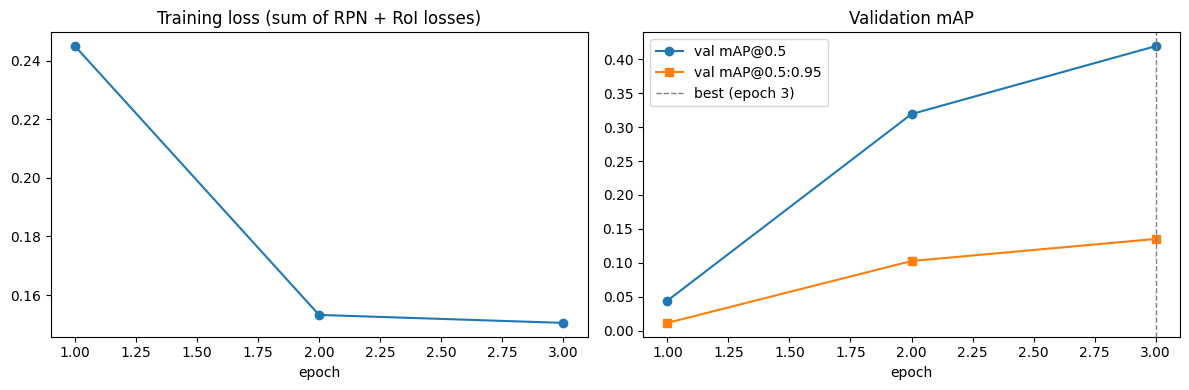

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["epoch"], history["train_loss"], marker="o")
ax[0].set_title("Training loss (sum of RPN + RoI losses)"); ax[0].set_xlabel("epoch")
ax[1].plot(history["epoch"], history["val_map50"], marker="o", label="val mAP@0.5")
ax[1].plot(history["epoch"], history["val_map"], marker="s", label="val mAP@0.5:0.95")
ax[1].axvline(best_epoch, color="grey", ls="--", lw=1, label=f"best (epoch {best_epoch})")
ax[1].set_title("Validation mAP"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

### 8. Evaluation on the held-out test split

The best checkpoint is reloaded and evaluated once on the test split — the same images the other
two models are tested on.

In [9]:
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

test_metrics = evaluate(model, loaders["test"], class_metrics=True)
pr = precision_recall_at(model, loaders["test"], score_thr=0.5, iou_thr=0.5)

summary = {
    "precision": pr["precision"],
    "recall":    pr["recall"],
    "mAP50":     float(test_metrics["map_50"]),
    "mAP75":     float(test_metrics["map_75"]),
    "mAP50_95":  float(test_metrics["map"]),
}
summary["f1"] = (2 * summary["precision"] * summary["recall"] /
                 max(summary["precision"] + summary["recall"], 1e-9))

print(f"{'metric':<14}{'value':>9}")
for k, v in summary.items():
    print(f"{k:<14}{v:>9.4f}")
print(f"\nTP={pr['tp']}  FP={pr['fp']}  FN={pr['fn']}  (conf>=0.5, IoU>=0.5)")

Loaded checkpoint from epoch 3
metric            value
precision        0.7143
recall           0.1645
mAP50            0.4669
mAP75            0.0499
mAP50_95         0.1640
f1               0.2674

TP=50  FP=20  FN=254  (conf>=0.5, IoU>=0.5)


### 9. Per-class results

class               mAP50-95   mAR@100
missing_hole           0.412     0.509
mouse_bite             0.144     0.363
open_circuit           0.133     0.280
short                  0.127     0.298
spur                   0.079     0.258
spurious_copper        0.089     0.248


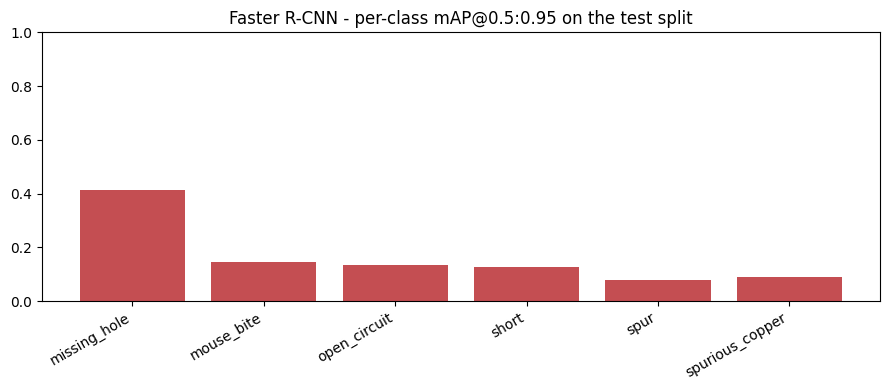

In [10]:
per_class = {}
cls_ids   = [int(c) for c in test_metrics["classes"].tolist()]
map_pc    = test_metrics["map_per_class"].tolist()
mar_pc    = test_metrics["mar_100_per_class"].tolist()
for cid, ap, ar in zip(cls_ids, map_pc, mar_pc):
    per_class[CLASS_NAMES[cid - 1]] = {"mAP50_95": float(ap), "mAR100": float(ar)}

print(f"{'class':<18}{'mAP50-95':>10}{'mAR@100':>10}")
for n, m in per_class.items():
    print(f"{n:<18}{m['mAP50_95']:>10.3f}{m['mAR100']:>10.3f}")

names = list(per_class)
plt.figure(figsize=(9, 4))
plt.bar(names, [per_class[n]["mAP50_95"] for n in names], color="#C44E52")
plt.xticks(rotation=30, ha="right"); plt.ylim(0, 1)
plt.title("Faster R-CNN - per-class mAP@0.5:0.95 on the test split")
plt.tight_layout(); plt.show()

### 10. Inference speed

Measured the same way as in notebooks 01 and 03: ten warm-up images, then one image at a time.
Faster R-CNN's two-stage pipeline plus NMS is expected to be several times slower than the two
end-to-end models — this is the quantitative form of the trade-off argued in Section 2.4.4.

In [11]:
model.eval()
test_images = sorted((IMG_ROOT / "test").glob("*.jpg"))
with torch.no_grad():
    for p in test_images[:10]:
        model([TF.to_tensor(Image.open(p).convert("RGB")).to(DEVICE)])
    if CUDA:
        torch.cuda.synchronize()

    latencies = []
    for p in test_images:
        x = TF.to_tensor(Image.open(p).convert("RGB")).to(DEVICE)
        t = time.perf_counter()
        model([x])
        if CUDA:
            torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t) * 1000)

lat_mean, lat_std = float(np.mean(latencies)), float(np.std(latencies))
fps = 1000.0 / lat_mean
print(f"Images timed      : {len(test_images)}")
print(f"Latency per image : {lat_mean:.2f} +/- {lat_std:.2f} ms")
print(f"Throughput        : {fps:.1f} FPS  (includes RPN + RoI head + NMS)")

Images timed      : 72
Latency per image : 2612.09 +/- 80.24 ms
Throughput        : 0.4 FPS  (includes RPN + RoI head + NMS)


### 11. Qualitative results

Green = ground truth, red = prediction (confidence >= 0.5). Overlapping green and red boxes are
correct detections; a green box on its own is a missed defect.

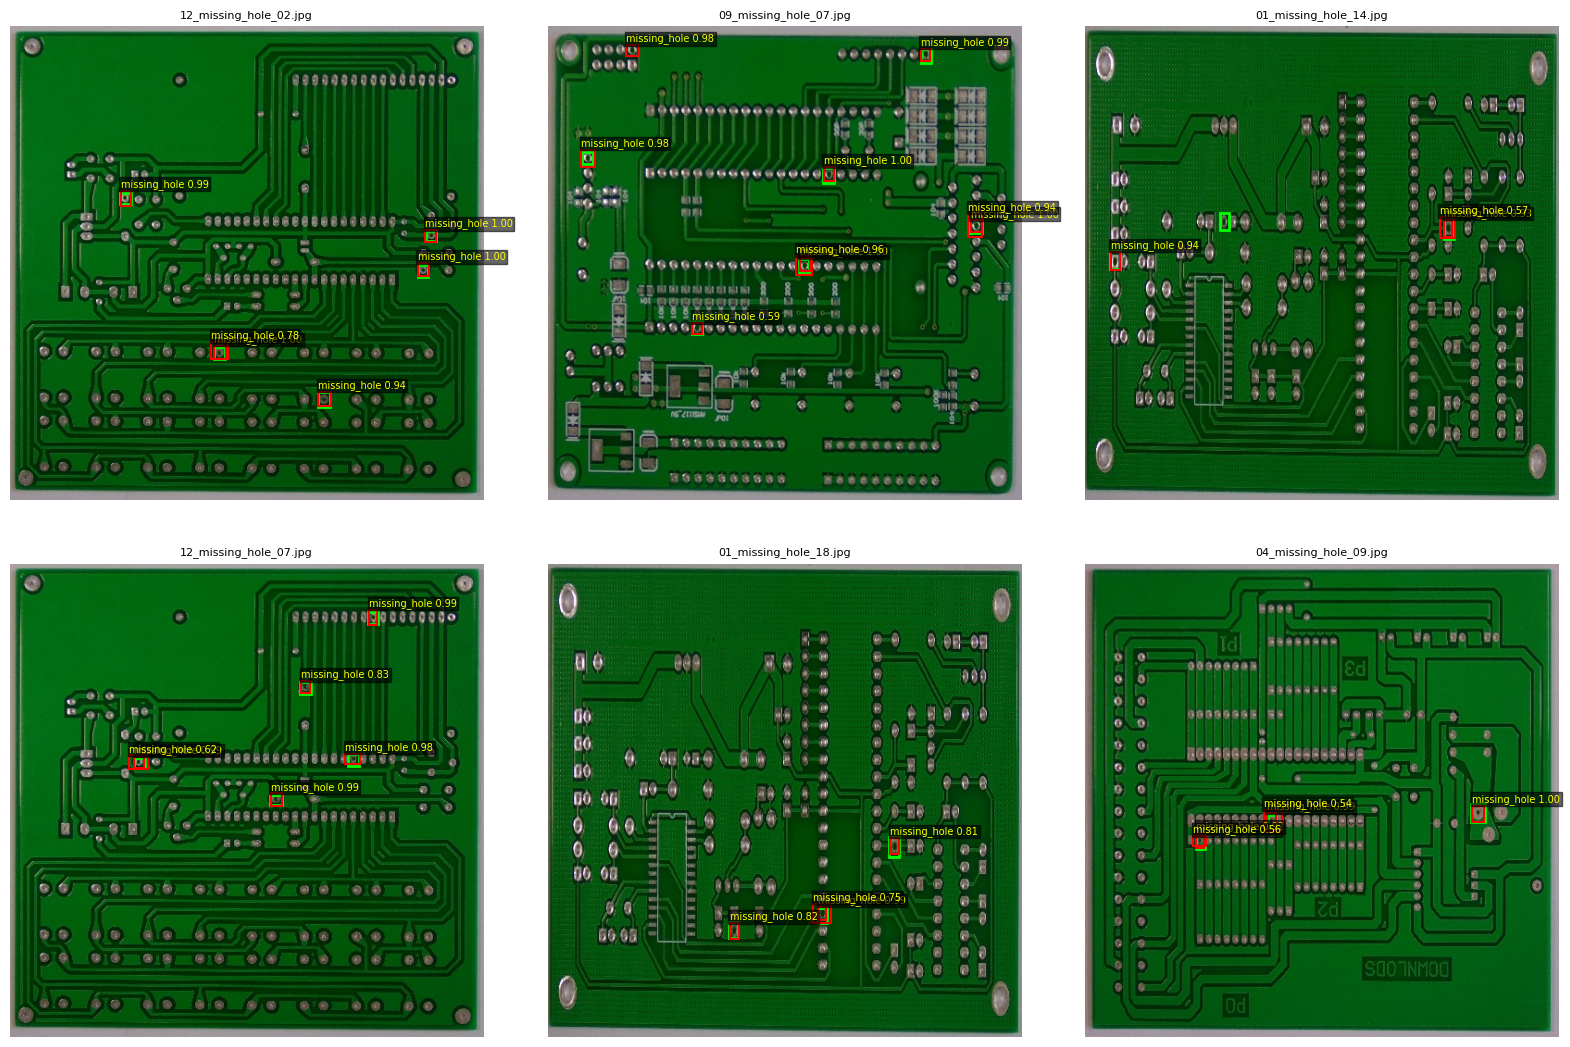

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
with torch.no_grad():
    for ax, idx in zip(axes.ravel(), range(min(6, len(datasets["test"])))):
        img, tgt = datasets["test"][idx]
        pred = model([img.to(DEVICE)])[0]
        ax.imshow(img.permute(1, 2, 0).numpy())
        for b in tgt["boxes"].numpy():
            ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                       fill=False, edgecolor="lime", linewidth=2.0))
        keep = pred["scores"] >= 0.5
        for b, l, s in zip(pred["boxes"][keep].cpu().numpy(),
                           pred["labels"][keep].cpu().numpy(),
                           pred["scores"][keep].cpu().numpy()):
            ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                       fill=False, edgecolor="red", linewidth=1.5))
            ax.text(b[0], max(b[1] - 4, 8), f"{CLASS_NAMES[l-1]} {s:.2f}",
                    color="yellow", fontsize=7, bbox=dict(facecolor="black", alpha=.6, pad=1))
        ax.set_title(datasets["test"].images[idx]["file_name"], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

### 12. Save the results

Written in the same schema as `results/yolov10.json` so notebook 04 can load all three without
special-casing.

In [13]:
payload = {
    "model": "Faster R-CNN",
    "variant": "fasterrcnn_resnet50_fpn_v2" + ("_smallanchors" if SMALL_ANCHORS else ""),
    "framework": f"torchvision {torchvision.__version__}",
    "type": "two-stage (RPN + RoIAlign, with NMS)",
    "pretrained": PRETRAINED,
    "params_M": round(n_params / 1e6, 2),
    "epochs": EPOCHS,
    "imgsz": INFO["image_size"],
    "batch": BATCH_SIZE,
    "device": "GPU" if CUDA else "CPU",
    "train_time_min": round(train_time / 60, 2),
    "best_epoch": best_epoch,
    "test": summary,
    "per_class": per_class,
    "counts": {k: pr[k] for k in ("tp", "fp", "fn")},
    "latency_ms": round(lat_mean, 2),
    "latency_std_ms": round(lat_std, 2),
    "fps": round(fps, 1),
    "weights": str(BEST_CKPT),
}
out = RESULTS_DIR / "faster_rcnn.json"
out.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("Saved", out)
print(json.dumps({k: v for k, v in payload.items() if k != "per_class"}, indent=2))

Saved C:\Users\User\Image-Processing\Student3-Defect Detection\results\faster_rcnn.json
{
  "model": "Faster R-CNN",
  "variant": "fasterrcnn_resnet50_fpn_v2_smallanchors",
  "framework": "torchvision 0.28.0+cpu",
  "type": "two-stage (RPN + RoIAlign, with NMS)",
  "pretrained": true,
  "params_M": 43.28,
  "epochs": 3,
  "imgsz": 512,
  "batch": 2,
  "device": "CPU",
  "train_time_min": 182.18,
  "best_epoch": 3,
  "test": {
    "precision": 0.7142857142857143,
    "recall": 0.16447368421052633,
    "mAP50": 0.4668736457824707,
    "mAP75": 0.04994519427418709,
    "mAP50_95": 0.16401799023151398,
    "f1": 0.26737967914438504
  },
  "counts": {
    "tp": 50,
    "fp": 20,
    "fn": 254
  },
  "latency_ms": 2612.09,
  "latency_std_ms": 80.24,
  "fps": 0.4,
  "weights": "C:\\Users\\User\\Image-Processing\\Student3-Defect Detection\\runs\\faster_rcnn\\best.pt"
}
